In [8]:
pip install -q dagshub mlflow

In [10]:
# import dagshub
# dagshub.init(repo_owner='Yaxh8074', repo_name='sentiment-analysis-of-yt-comment', mlflow=True)

### DagsHub Authorization

To authorize DagsHub, please follow these steps:

1.  **Generate a DagsHub Token**: Go to your DagsHub profile settings -> 'Access Tokens' and generate a new token. Copy this token.
2.  **Paste the Token Below**: Replace `'YOUR_DAGSHUB_TOKEN'` with the token you just generated.
3.  **Run the Cell**: Execute the following Python cell to authorize DagsHub.

In [11]:
import os
import dagshub

# Replace 'YOUR_DAGSHUB_USERNAME' with your actual DagsHub username
# Replace 'YOUR_DAGSHUB_TOKEN' with your actual DagsHub token
DAGSHUB_USERNAME = 'Yaxh8074' # @param {type: "string"}
DAGSHUB_TOKEN = '59bcdf60df1e532f015db888752a8050e6e883e9' # @param {type: "string"}

os.environ['DAGSHUB_USERNAME'] = DAGSHUB_USERNAME
os.environ['DAGSHUB_TOKEN'] = DAGSHUB_TOKEN

After successfully authenticating, please re-run the `dagshub.init` cell to ensure the connection is established with your repository.

In [12]:
import numpy as np
import pandas as pd

In [13]:
df = pd.read_csv('/content/preprocessed_data.csv')
df.head()

,comment,category,word_count,char_count,avg_word_length
0,family mormon never tried explain still stare ...,1,26,199,7.370370
1,buddhism much lot compatible christianity espe...,1,140,990,7.021277
2,seriously say thing first get complex explain ...,-1,46,275,5.851064
3,learned want teach different focus goal not wr...,0,15,101,6.312500
4,benefit may want read living buddha living chr...,1,68,478,6.927536


In [14]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
X = df.drop('category', axis=1)
y = df['category']

In [16]:
# Step 1: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['category'])

In [17]:
# Step 2: Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=10000)

In [18]:
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [21]:
# Fit and transform the training data and transform the test data
train_text = X_train['comment'].fillna(' ').astype(str)
test_text = X_test['comment'].fillna('').astype(str)
X_train_bow = vectorizer.fit_transform(train_text)
X_test_bow = vectorizer.transform(test_text)

In [24]:
# Fit and transform the training data and transform the test data
X_train_bow = vectorizer.fit_transform(X_train['comment'].fillna('').astype(str))
X_test_bow = vectorizer.transform(X_test['comment'].fillna('').astype(str))

# Convert the sparse matrix to DataFrame
X_train_bow_df = pd.DataFrame(X_train_bow.toarray(), columns=vectorizer.get_feature_names_out())
X_test_bow_df = pd.DataFrame(X_test_bow.toarray(), columns=vectorizer.get_feature_names_out())

# Combine the BOW features with the original columns for training data
X_train_combined = pd.concat([X_train, X_train_bow_df], axis=1)
X_test_combined = pd.concat([X_test, X_test_bow_df], axis=1)

# Drop the original 'comment' column to avoid redundancy if it was explicitly added
# Note: This drop might not be strictly necessary if 'comment' is handled separately or not included directly in X_train_bow_df
# Re-evaluating based on the original problem and flow, it seems the intent was to combine BOW with other features if any
# Given X_train already contains 'comment', and we are converting it to BOW, dropping 'comment' from X_train_combined might be appropriate if other features are also present.
# For now, let's keep it consistent with the intent of combining numeric features + BOW and dropping the original text column.

X_train_combined.drop('comment', axis=1, inplace=True)
X_test_combined.drop('comment', axis=1, inplace=True)

In [25]:
X_train

,comment,word_count,char_count,avg_word_length
0,actually part familiar pattern swami adityanat...,79,575,7.187500
1,fan start milk abhishekam already wait,6,39,5.571429
2,sure name added latest hit list bjp r,8,39,4.333333
3,people live glass house throw stone,6,37,5.285714
4,free speech not freedom consequence,5,36,6.000000
...,...,...,...,...
29434,damn compulsory qualification required like le...,13,91,6.500000
29435,fucking hell vegetable offend see outside feel...,16,113,6.647059
29436,love describe cap haha really full time,7,41,5.125000
29437,love not rich western nation leading way fight...,13,88,6.285714


In [26]:
X_train_bow_df

,000,0070,0aplease,100,1000,10000,101,103,104,105,...,zero,zindabad,zing,zomato,zombie,zonal,zone,zoom,zor,zuckerberg
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29434,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29436,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29437,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
X_train_combined

,word_count,char_count,avg_word_length,000,0070,0aplease,100,1000,10000,101,...,zero,zindabad,zing,zomato,zombie,zonal,zone,zoom,zor,zuckerberg
0,79,575,7.187500,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,6,39,5.571429,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8,39,4.333333,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,37,5.285714,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,36,6.000000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29434,13,91,6.500000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29435,16,113,6.647059,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29436,7,41,5.125000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29437,13,88,6.285714,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
y_train

,category
0,-1
1,0
2,1
3,1
4,1
...,...
29434,0
29435,-1
29436,1
29437,1


In [29]:
# Set or create an experiment
mlflow.set_experiment("Exp 1 - RF Baseline")

2026/03/02 06:30:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/02 06:30:18 INFO mlflow.store.db.utils: Updating database tables
2026/03/02 06:30:19 INFO mlflow.tracking.fluent: Experiment with name 'Exp 1 - RF Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1772433019564, experiment_id='1', last_update_time=1772433019564, lifecycle_stage='active', name='Exp 1 - RF Baseline', tags={}, workspace='default'>

2026/03/02 06:30:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 06:30:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/02 06:30:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 06:30:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Accuracy: 0.6028532608695653


/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference tim

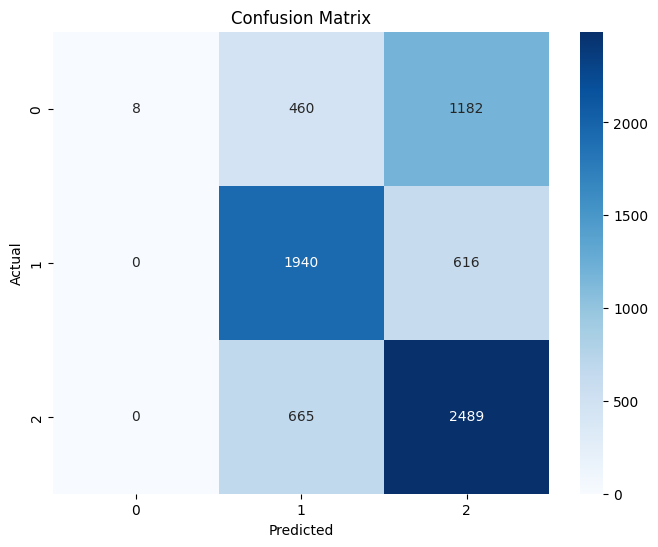

In [30]:
# Step 3: Define and train a Random Forest baseline model using a simple train-test split
with mlflow.start_run() as run:
    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split")

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train_combined, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test_combined)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Save and log the confusion matrix plot
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # Log the Random Forest model and vectorizer
    # Note: X_train_combined is sparse matrix, convert sample to array for signature
    mlflow.sklearn.log_model(model, "random_forest_model")
    mlflow.sklearn.log_model(vectorizer, "vectorizer")

    # Log the dataset - create copies to avoid modifying originals
    train_df = X_train.copy()
    train_df['target'] = y_train.values
    dataset = mlflow.data.from_pandas(train_df, targets="target")
    mlflow.log_input(dataset, context="training")

    test_df = X_test.copy()
    test_df['target'] = y_test.values
    dataset = mlflow.data.from_pandas(test_df, targets="target")
    mlflow.log_input(dataset, context="validation")

# Display final accuracy
print(f"Accuracy: {accuracy}")

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.00      0.01      1650
           0       0.63      0.76      0.69      2556
           1       0.58      0.79      0.67      3154

    accuracy                           0.60      7360
   macro avg       0.74      0.52      0.46      7360
weighted avg       0.69      0.60      0.53      7360

